# LangGraph

## 1) Basics

In [ ]:
from typing import TypedDict    # Pydantic을 사용해도 됨
from langgraph.graph import StateGraph, START, END

In [2]:
class MyState(TypedDict):
    user_input: str
    result: str

In [3]:
def mainagent_node(state: MyState) -> MyState:
    query = state['user_input']
    # llm agent로 query 실행
    
    return {
        'result': f"에이전트의 결과는 1234 입니다."
    }

In [4]:
graph_builder = StateGraph(MyState)

graph_builder.add_node('mainagent', mainagent_node)

graph_builder.add_edge(START, 'mainagent')

graph_builder.add_edge('mainagent', END)

In [5]:
basic_app = graph_builder.compile()

result = basic_app.invoke({'user_input': '안녕하세요'})
result

{'user_input': '안녕하세요', 'result': '에이전트의 결과는 1234 입니다.'}

## 2) Examples

### a) 책 주제 -> 책 제목 LangGraph

In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [69]:
from typing import TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

from collections.abc import Callable
from langgraph.types import Command
from langchain.agents.middleware import ModelFallbackMiddleware, ModelRequest, ModelResponse, wrap_model_call
from langchain_google_genai import ChatGoogleGenerativeAI # gpt-5.4-mini가 되지 않으면 gemini로 바꿈

In [70]:
# 1. State 정의
class BookState(TypedDict):
    topic: str
    title: str

# structured output schema
class BookTitleOutput(BaseModel):
    title: str = Field(description='사용자의 책의 주제를 바탕으로 선정된 제목 1개')

In [71]:
# Fallback model
gemini_fallback = ChatGoogleGenerativeAI(
    model='gemini-3.1-flash',
    temperature=0
)

# Fallback Middleware
@wrap_model_call
def fallback_model_middleware(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse | Command]
) -> ModelResponse | Command:
    try:
        result = handler(request)
        return result
    
    except Exception as e:
        request.model = gemini_fallback
        
        return handler(request)

In [ ]:
# 2. LLM 준비
model = ChatOpenAI(
    model = 'google/gemma-4-26B-A4B-it',
    base_url="http://100.95.34.69:8001/v1",
    api_key='dummy',
)

llm = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(BookTitleOutput),
    system_prompt="""
    당신은 세계에서 제일 유명한 출판사의 메인 기획자입니다.
    사용자가 책의 주제를 입력하면 아래 조건을 만족하는 책의 제목을 1개만 자연스럽게 만들어주세요.
    
    [조건]
    - 짧고 명확하게 작성할 것
    - 너무 과장된 표현은 피할 것
    - 제목만 출력할 것
    - 베스트셀러가 될 제목으로만 만들 것
    - 주제와 제목이 같지 않을 것
    """,
    middleware=[
        fallback_model_middleware,
        ModelFallbackMiddleware(
            "openai:gpt-5.4-mini",
            gemini_fallback,
            'anthropic:claude-sonnet-4-5'
        )
    ]
)


In [73]:
# 3. Node 정의
def make_title_node(state: BookState) -> BookState:
    topic = state['topic']
    
    response = llm.invoke(
        {
            'messages': [
                {
                    'role': 'user',
                    'content': f"책의 주제: {topic}"
                }
            ]
        }
    )
    
    structured_output: BookTitleOutput = response['structured_response']  # {title: '책 제목'}
    
    return {
        'title': structured_output.title
    }

In [74]:
# 4. 그래프 생성
graph_builder = StateGraph(BookState)

# 5. 노드 추가
graph_builder.add_node('make_title', make_title_node)

# 6. 엣지 연결
graph_builder.add_edge(START, 'make_title')
graph_builder.add_edge('make_title', END)

# 7. 컴파일
graph = graph_builder.compile()

# 8. 실행
result = graph.invoke({'topic': '초등학생을 위한 RAG 에이전트 개발'})

In [75]:
print(result)
print("생성된 책 제목:", result["title"])

{'topic': '초등학생을 위한 RAG 에이전트 개발', 'title': '나만의 똑똑한 AI 비서 만들기'}
생성된 책 제목: 나만의 똑똑한 AI 비서 만들기


## 3) Conditional Branch & Loop

In [76]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [78]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [84]:
class MyState(TypedDict):
    question: str
    result: str

def router(state: MyState) -> str:
    question = state['question']
    
    if '계산' in question:
        return 'calculator'
    
    return 'answer'

def calculator_node(state: MyState) -> int:
    return {
        'result': "계산을 완료했습니다."
    }

In [85]:
def answer_node(state: MyState) -> MyState:
    return {
        'result': "일반 답변 노드로 이동했습니다."
    }

In [86]:
# create a graph
graph_builder = StateGraph(MyState)

# create nodes
graph_builder.add_node('calculator', calculator_node)
graph_builder.add_node('answer', answer_node)

# add conditional branch
graph_builder.add_conditional_edges(START, router)

# connect nodes with edges
graph_builder.add_edge('calculator', END)
graph_builder.add_edge('answer', END)

# compile graph
graph = graph_builder.compile()

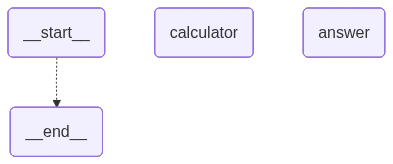

In [87]:
graph

In [88]:
print(f"{graph.invoke({'question': "이 문제를 계산해줘."})}")

{'question': '이 문제를 계산해줘.', 'result': '계산을 완료했습니다.'}


In [89]:
print(f"{graph.invoke({'question': "RAG가 뭐야?"})}")

{'question': 'RAG가 뭐야?', 'result': '일반 답변 노드로 이동했습니다.'}


# Architectures

## 1) ReAct Agent

In [92]:
from typing import Annotated, TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

In [ ]:
# 1. State 정의
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

# 2. 도구 정의
@tool
def add(a: int, b: int) -> int:
    """두 정수를 더합니다."""
    print(f'tool: add  a: {a}, b: {b}')
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """두 정수를 곱합니다."""
    print(f'tool: multiply  a: {a}, b: {b}')
    return a * b

tools = [add, multiply]

In [94]:
# 3. 모델 정의
model = ChatOpenAI(
    model='gpt-5.4-mini',
    temperature=0
)

## 도구 붙이기 ##
model_with_tools = model.bind_tools(tools)

In [102]:
# 4. Agent Node 정의
def agent_node(state: AgentState) -> str:
    response = model_with_tools.invoke(state['messages'])
    print('Agent response : ', response)
    return {
        'messages': [response]
    }


# 5. 조건 분기 함수
def should_continue(state: AgentState):
    last_message = state['messages'][-1]
    
    if last_message.tool_calls:
        return 'tools'
    else:
        return END


# 6. Tool Node 정의
tool_node = ToolNode(tools)

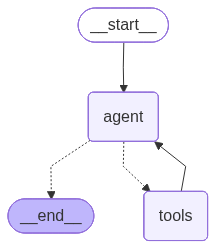

In [103]:
# 7. 그래프 구성
graph_builder = StateGraph(AgentState)

graph_builder.add_node('agent', agent_node)
graph_builder.add_node('tools', tool_node)

graph_builder.add_edge(START, 'agent')

graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    {
        'tools': 'tools',
        END: END
    }
)

graph_builder.add_edge('tools', 'agent')        # 양방향 간선


# 8. 그래프 컴파일
graph = graph_builder.compile()

graph

In [105]:
# 9. 실행
result = graph.invoke(
    {
        'messages': [
            HumanMessage(content="3과 5를 더하고, 그 결과에 10을 곱해줘.")
        ]
    }
)

result
print(f"{result['messages'][-1].content}")

Agent response :  content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 170, 'total_tokens': 190, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DZRjpcifFmJCjwrFsDcGn4KIYIlP8', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019dd1bf-6d36-7240-9989-47c3d930f08d-0' tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_f8xZi4SuSLJuDk8V7j2Nw3nq', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 170, 'output_tokens': 20, 'total_tokens': 190, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
Agent response :  content='' 

## 2) Parallelization

In [106]:
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [108]:
model = init_chat_model('openai:gpt-5.4-nano')

In [110]:
# 1. State 정의
class WriterState(TypedDict):
    topic: str
    sns: str
    youtube: str
    blog: str
    final_report: str

In [118]:
# 2. 노드 정의
def write_sns_node(state: WriterState) -> WriterState:
    topic = state['topic']
    
    print('sns 홍보안 작성')
    
    result = model.invoke(f"'{topic}'에 대한 SNS 홍보안의 핵심만 작성해줘.")
    
    return {
        'sns': result.content       # init_chat_model()의 .content의 반환값으로 내용이 반환됨.
    }

def write_youtube_node(state: WriterState) -> WriterState:
    topic = state['topic']
    
    print('Youtube 홍보안 작성')
    
    result = model.invoke(f"'{topic}'에 대한 주제로 Youtube 홍보안 핵심만 작성해줘.")
    
    return {
        'youtube': result.content
    }
    
def write_blog_node(state: WriterState) -> WriterState:
    topic = state['topic']
    
    print('Blog 홍보안 작성')
    
    result = model.invoke(f"'{topic}'을 주제로 Blog 홍보안 핵심만 작성해줘.")
    
    return {
        'blog': result.content
    }

In [123]:
def aggregator(state: WriterState):
    final_text = f"""
    [주제]
    {state['topic']} 홍보안
    
    [내용]
    1. sns 홍보안
    ----------------------------------------
    {state['sns']}
    ----------------------------------------
    
    2. youtube 홍보안
    ----------------------------------------
    {state['youtube']}
    ----------------------------------------
    
    3. blog 홍보안
    ----------------------------------------
    {state['blog']}
    ----------------------------------------
    """
    
    result = model.invoke(f"{final_text}의 내용을 가지고 홍보 보고서를 작성해줘.")
    
    return {
        'final_report': result.content
    }

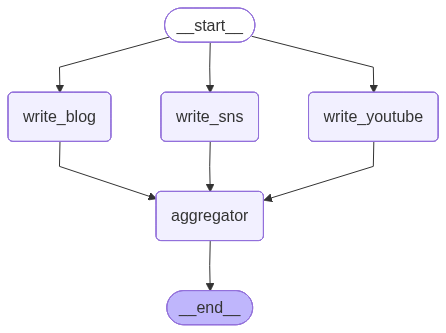

In [124]:
graph_builder = StateGraph(WriterState)

graph_builder.add_node('write_sns', write_sns_node)
graph_builder.add_node('write_youtube', write_youtube_node)
graph_builder.add_node('write_blog', write_blog_node)
graph_builder.add_node('aggregator', aggregator)

graph_builder.add_edge(START, 'write_sns')
graph_builder.add_edge(START, 'write_youtube')
graph_builder.add_edge(START, 'write_blog')

graph_builder.add_edge('write_sns', 'aggregator')
graph_builder.add_edge('write_youtube', 'aggregator')
graph_builder.add_edge('write_blog', 'aggregator')

graph_builder.add_edge('aggregator', END)

graph = graph_builder.compile()
graph

In [ ]:
result = graph.invoke(
    {
        'topic': '고양 꽃축제'
    }
)
result

Blog 홍보안 작성
sns 홍보안 작성
Youtube 홍보안 작성


{'topic': '고양 꽃축제',
 'sns': '- **행사명**: 고양 꽃축제  \n- **핵심 키워드**: 만개한 꽃, 산책, 포토스팟, 가족나들이  \n- **메시지 한 줄**: “꽃향기 가득한 고양에서 인생샷 찍고 힐링하자!”  \n- **추천 콘텐츠**: 개화 현장 사진/영상 + 하이라이트(가장 예쁜 구역) + 포토존 인증  \n- **해시태그**: #고양꽃축제 #고양 #꽃구경 #인생샷 #가족나들이 #봄나들이  \n- **CTA(행동유도)**: “지금 일정 확인하고 방문해보세요!”',
 'youtube': '- **주제(핵심):** “고양 꽃축제” 하이라이트와 현장 분위기 한 번에 보기  \n- **타겟 키워드:** 고양 꽃축제, 고양 꽃박람회, 봄꽃, 꽃구경, 나들이, 데이트 코스, 가족여행  \n- **영상 콘셉트(훅):** “지금 가야 하는 이유 3가지 + 베스트 포토스팟”  \n- **홍보 포인트(핵심만):** 포토존/전시 정원/야간 명소/꽃길 동선(짧게 요약)  \n- **CTA(구독 유도):** “다음 편(맛집·주차·동선)도 보려면 구독!” + “댓글로 가고 싶은 포토스팟 남기기”  \n- **제목 예시:** “고양 꽃축제 핵심만! 포토스팟·꽃길 동선 총정리(나들이 필수)”  \n- **썸네일 문구 예시:** “포토존 BEST 5” / “꽃길 루트” / “지금 가세요!”  \n- **해시태그 예시:** #고양꽃축제 #꽃축제 #고양여행 #봄나들이 #데이트코스 #가족여행',
 'blog': '## 고양 꽃축제 Blog 홍보안 핵심\n\n- **한 줄 키워드(도입)**: “고양에서 만나는 계절의 향기, 고양 꽃축제로 봄 감성 충전!”\n- **핵심 매력 포인트(3가지)**  \n  1) **다채로운 꽃 전시/테마**: 봄 분위기 가득한 포토 스팟  \n  2) **산책 코스 & 즐길거리**: 가족·연인 모두 만족하는 데이트/나들이  \n  3) **포토존/이벤트**: 인생샷 + 참여형 프로그램으로 더 재밌게\n- **블로그 글 구성(권장 목차

In [128]:
print(f"{result['final_report']}")

## 고양 꽃축제 홍보 보고서(SNS·YouTube·Blog)

### 1) 목적 및 개요
본 보고서는 **“고양 꽃축제”**를 타깃별 채널(SNS, YouTube, Blog)에 맞춰 홍보하기 위한 콘텐츠 전략과 운영 방향을 정리한 문서입니다.  
핵심 목표는 **현장 방문 유도(CTA 강화)**와 **포토스팟/산책 가치(브랜딩 메시지 일관화)**를 통해 사전 관심을 확보하고 방문 전환율을 높이는 것입니다.

---

## 2) SNS 홍보안

### 가. 기본 정보
- **행사명**: 고양 꽃축제  
- **핵심 키워드**: 만개한 꽃, 산책, 포토스팟, 가족나들이  
- **메시지 한 줄**:  
  - **“꽃향기 가득한 고양에서 인생샷 찍고 힐링하자!”**
- **추천 콘텐츠**
  1) 개화 현장 **사진/영상**  
  2) **하이라이트**(가장 예쁜 구역) 짧은 소개  
  3) **포토존 인증**(참여형/UGC 유도)

### 나. 해시태그
- **#고양꽃축제 #고양 #꽃구경 #인생샷 #가족나들이 #봄나들이**

### 다. CTA(행동유도)
- **“지금 일정 확인하고 방문해보세요!”**

### 라. 운영 포인트(권장)
- 이미지/영상은 **“꽃 만개 + 포토스팟”** 중심으로 구성
- 게시물마다 **짧은 한 줄 메시지 + 위치/방문 이유**를 붙여 이탈을 최소화
- 포토존/인증 요소로 자연스럽게 **공유 확산(재방문·재인증 유도)**

---

## 3) YouTube 홍보안

### 가. 주제(핵심)
- **“고양 꽃축제” 하이라이트와 현장 분위기 한 번에 보기**

### 나. 타겟 키워드
- 고양 꽃축제, 고양 꽃박람회, 봄꽃, 꽃구경, 나들이, 데이트 코스, 가족여행

### 다. 영상 콘셉트(훅)
- **“지금 가야 하는 이유 3가지 + 베스트 포토스팟”**  
  (첫 10~20초 내 훅으로 시청 지속 유도)

### 라. 홍보 포인트(핵심만)
- 포토존 / 전시 정원 / 야간 명소 / 꽃길 동선  
  → **짧고 명확하게 요

## 3) Evaluator

In [131]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END

class State(TypedDict):
    question: str
    answer: str
    evaluation: str
    retry_count: int


def generate_answer_node(state: State):
    # 실제로는 LLM 호출
    answer = f"{state['question']}에 대한 초안 답변입니다."
    
    return {
        'answer': answer
    }
    

def evaluate_answer_node(state: State):
    answer = state['answer']
    
    # 실제로는 LLM-as-a-judge 또는 규칙 기반 평가 사용
    if '근거' in answer:
        evaluation = 'pass'
    else:
        evaluation = 'fail'
    
    return {
        'evaluation': evaluation
    }


def improve_answer_node(state:State):
    improved = state['answer'] + '근거를 포함하여 답변을 보완했습니다.'
    return {
        'answer': improved,
        'retry_count': state['retry_count'] + 1
    }
    
    
def route_after_evaluation(state: State) -> Literal['improve', 'end']:
    if state['evaluation'] == 'pass':
        return 'end'
    
    if state['retry_count'] >= 2:
        return 'end'
    
    return 'improve'

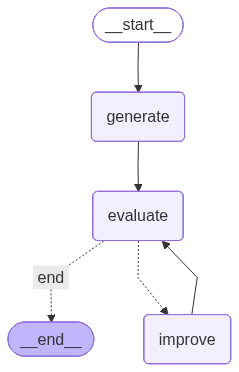

In [132]:
graph_builder = StateGraph(State)

graph_builder.add_node('generate', generate_answer_node)
graph_builder.add_node('evaluate', evaluate_answer_node)
graph_builder.add_node('improve', improve_answer_node)

graph_builder.set_entry_point('generate')

graph_builder.add_edge('generate', 'evaluate')

graph_builder.add_conditional_edges(
    'evaluate',
    route_after_evaluation,
    {
        'improve': 'improve',
        'end': END
    }
)

graph_builder.add_edge('improve', 'evaluate')

graph = graph_builder.compile()
graph

In [133]:
result = graph.invoke(
    {
        'question': "RAG란 무엇인가요?",
        'answer': "",
        'evaluation': "",
        'retry_count': 0
    }
)

print(result["answer"])

RAG란 무엇인가요?에 대한 초안 답변입니다.근거를 포함하여 답변을 보완했습니다.
